In [1]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import netCDF4
import numpy as np
import pandas as pd
import scipy.spatial
import trimesh
from scipy import sparse

from DDV import eigenbasis, sph_utils, kernel

# plt.rcParams['font.sans-serif'] = ['Outfit'] + plt.rcParams['font.sans-serif']

C:\Users\mg874\anaconda3\Lib\site-packages\tqdm_joblib\__init__.py:4: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
def read_data(data_handle, lons, lats, time):
    u = data_handle.variables['u'][time].data
    v = data_handle.variables['v'][time].data
    df = pd.DataFrame({
        "lon": lons.flatten(),
        "lat": lats.flatten(),
        "u": u.flatten(),
        "v": v.flatten(),
    })
    return df

In [3]:
data = netCDF4.Dataset('../data/07-2020-500hpa-uv.nc', 'r')

lons = data.variables['longitude'][:].data
lats = data.variables['latitude'][:].data
lon_mesh, lat_mesh = np.meshgrid(lons, lats)

df = read_data(data, lon_mesh, lat_mesh, 0)

lat_lim = 90

df_prefilter = df[np.abs(df['lat']) < lat_lim]

In [4]:
df_filter2 = df_prefilter[(df_prefilter['lat'] % 1 == 0) & (df_prefilter['lon'] % 1 == 0)]

In [5]:
points2 = sph_utils.conv_lat_lon(df_filter2['lat'].to_numpy(), df_filter2['lon'].to_numpy(), r=1)

points_aug_n = np.array([[0, 0, 1]])
points_aug_s = np.array([[0, 0, -1]])

all_points = np.concatenate((points2, points_aug_n, points_aug_s))

all_ch = scipy.spatial.ConvexHull(all_points)

all_mesh = trimesh.Trimesh(all_ch.points, all_ch.simplices)

In [7]:
obs_vecs = sph_utils.project_to_xyz(points2, df_filter2['u'].to_numpy(), df_filter2['v'].to_numpy())

obs_vecs_mean_norm = np.mean(np.linalg.norm(obs_vecs, axis=1))

obs_vecs /= obs_vecs_mean_norm

In [8]:
filtered_lons = np.unique(df_filter2['lon'].to_numpy())
filtered_lats = np.unique(df_filter2['lat'].to_numpy())

stride = 10


In [9]:
def build_D_from_block_size(
        block_size,
        n_lat, n_lon,
        area_weights=None
):
    N = n_lat * n_lon
    B = block_size

    # 1. Calculate the initial floating-point center index (0.5 for B=2, 1.5 for B=4, 7.0 for B=15)
    initial_center = (B - 1) / 2.0
    stride = B

    # 2. Determine the floating-point centers for both dimensions
    # These centers are correct for both odd and even B
    centres_i_float = np.arange(initial_center, n_lat, stride)
    centres_j_float = np.arange(initial_center, n_lon, stride)

    n_centres = len(centres_i_float) * len(centres_j_float)

    centres_i_grid, centres_j_grid = np.meshgrid(centres_i_float, centres_j_float, indexing='ij')

    centres_i = centres_i_grid.ravel()
    centres_j = centres_j_grid.ravel()

    # --- Core Matrix Building Logic ---

    if area_weights is None:
        area_weights = np.ones(N, dtype=float)

    rows = []
    cols = []
    data = []

    # Calculate the offset for the lowest index in the patch relative to the center
    # For B=15 (center 7.0), offset is 7.0. i_start = 7.0 - 7.0 = 0.
    # For B=4 (center 1.5), offset is 1.5. i_start = 1.5 - 1.5 = 0.
    offset = (B - 1) / 2.0

    for idx in range(len(centres_i)):
        i_tilde = centres_i[idx]  # Latitude float center
        j_tilde = centres_j[idx]  # Longitude float center

        # Calculate the integer starting index (the lowest index) for the B x B patch
        # np.floor ensures we round down to the correct starting index.
        i_start = int(np.floor(i_tilde - offset))
        j_start = int(np.floor(j_tilde - offset))

        patch_indices = []

        # Iterate B indices for LATITUDE
        for di in range(B):
            i_grid = i_start + di

            # Latitude: Clamp at poles [0, n_lat-1]
            ii = min(max(i_grid, 0), n_lat - 1)

            # Iterate B indices for LONGITUDE
            for dj in range(B):
                j_grid = j_start + dj

                # Longitude: Cyclic wrap-around [0, n_lon-1]
                jj = j_grid % n_lon

                index = ii * n_lon + jj
                patch_indices.append(index)

        # Aggregate and normalize weights... (same as before)
        patch_indices = np.array(patch_indices)
        w = area_weights[patch_indices]
        w_sum = w.sum()

        if w_sum > 0:
            w = w / w_sum

        rows.extend([idx] * len(patch_indices))
        cols.extend(patch_indices.tolist())
        data.extend(w.tolist())

    D = sparse.csr_matrix((data, (rows, cols)), shape=(n_centres, N))
    return D


def build_H(D, dim=2):
    """For vector fields (2 components), interleaved flattening."""
    return sparse.kron(D, sparse.eye(dim), format='csr')


n_lat = len(filtered_lats)
n_lon = len(filtered_lons)

D = build_D_from_block_size(stride, n_lat, n_lon)
H = build_H(D, dim=3)

In [10]:
centres = D.dot(points2)

In [11]:
downscaled_vecs = D.dot(obs_vecs)

noisy_downscaled_vecs = downscaled_vecs + np.random.normal(scale=1e-2, size=downscaled_vecs.shape)

plat_ds, plon_ds, d_us_ds, d_vs_ds = sph_utils.project_to_latlon(centres, noisy_downscaled_vecs)


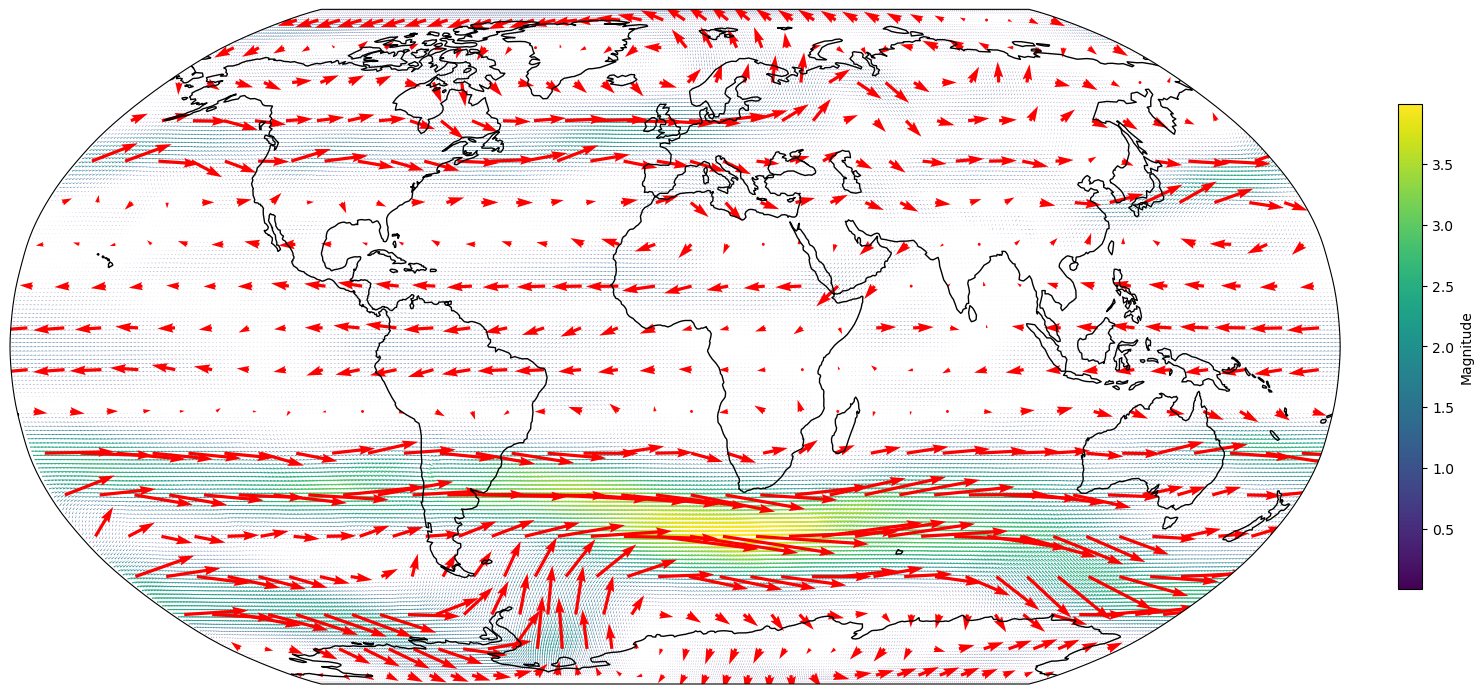

In [12]:
plat, plon, d_us, d_vs = sph_utils.project_to_latlon(points2, obs_vecs)

fig = plt.figure(figsize=(15, 10))
ax = plt.axes(projection=ccrs.Robinson())
ax.coastlines()

quiv = ax.quiver(plon, plat, d_us, d_vs, np.sqrt(np.power(d_us, 2) + np.power(d_vs, 2)), transform=ccrs.PlateCarree(),
                 headwidth=1, minlength=0)
quiv._init()
quiv2 = ax.quiver(plon_ds, plat_ds, d_us_ds, d_vs_ds, color='red', transform=ccrs.PlateCarree(), )  #, scale=quiv.scale)
plt.colorbar(mappable=quiv, label='Magnitude', fraction=0.04, pad=0.04, shrink=0.5)
# plt.title('Downscaled Monthly Average Wind Field Projected to Latitude/Longitude Grid', fontsize=20)
plt.tight_layout()
plt.show()
# plt.savefig('plots/averaged-wind.png', dpi=50 0)

In [13]:
sphere_eigen_val, sphere_eigen_vec_d, sphere_eigen_vec_c, vol, sph_c = eigenbasis.generate_vector_basis(
    all_mesh.vertices, all_mesh.faces, depth=500)

C:\Users\mg874\anaconda3\Lib\site-packages\pydec\dec\simplicial_complex.py:177: RuntimeWarning: divide by zero encountered in divide
  data.star_inv = sparse.spdiags([1.0/stardiag],[0], N, N, format='csr')
Processing eigenvectors:   0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

In [14]:
# Parameters for inference
params = {
    "k_d": 1,
    "k_c": 10,
    "s_d": 0,
    "s_c": 1,
    "v": 0.5
}


In [15]:
def get_prior_factors(eigenvalues, d_eigenfields, c_eigenfields, points, dim, params, vol, h_eigenfields=None):
    ms_d = kernel.matern_scaling(eigenvalues[1:], params["k_d"], params["v"], dim)
    ms_c = kernel.matern_scaling(eigenvalues[1:], params["k_c"], params["v"], dim)

    ms_d_scaled = ms_d / np.sqrt(eigenvalues[1:])
    ms_c_scaled = ms_c / np.sqrt(eigenvalues[1:])

    def get_sparse_fields(fields, pts, skip_first_mode=True):
        if skip_first_mode:
            subset = fields[pts, :, 1:]
        else:
            subset = fields[pts, :, :]

        N, D, M = subset.shape
        flat_subset = subset.reshape(N * D, M)
        return sparse.csr_matrix(flat_subset)

    # Get unscaled eigenfields
    D = get_sparse_fields(d_eigenfields, points, skip_first_mode=True)
    C = get_sparse_fields(c_eigenfields, points, skip_first_mode=True)

    # Create diagonal scaling matrices
    S_d = sparse.diags(np.sqrt(ms_d_scaled))  # sqrt because we'll multiply twice
    S_c = sparse.diags(np.sqrt(ms_c_scaled))

    c_d = np.sum(ms_d_scaled) / vol
    c_c = np.sum(ms_c_scaled) / vol

    var_d = (params["s_d"] ** 2) / c_d
    var_c = (params["s_c"] ** 2) / c_c

    # V_d = sqrt(var_d) * D * sqrt(S_d)
    # V_c = sqrt(var_c) * C * sqrt(S_c)
    V_d = np.sqrt(var_d) * D.dot(S_d)
    V_c = np.sqrt(var_c) * C.dot(S_c)

    V = sparse.hstack([V_d, V_c])

    return V


V = get_prior_factors(sphere_eigen_val, sphere_eigen_vec_d, sphere_eigen_vec_c, range(len(points2)), 3, params, vol)

# 2. Compute F = H V (The forward model applied to the factors)
# H is the observation operator
V = V.astype(np.float64)  # Ensure the sparse factor has correct dtype
F = H.dot(V).astype(np.float64)  # F is dense or sparse based on H.dot(V), ensure float64

# 3. Compute sigma_barbar (implicitly: F F^T)
sigma_barbar = F.dot(F.T).astype(np.float64)  # Enforce float64 for the crucial P x P matrix

# 4. Standard Conditioning (P is the number of observations)
factor_nug = 1e-2
# Ensure sigma_barbar_n is built from float64 and is factorizable
sigma_barbar_n = sigma_barbar + factor_nug * sparse.eye(sigma_barbar.shape[0], format='csr', dtype=np.float64)

obs = noisy_downscaled_vecs.reshape(-1).astype(np.float64)  # Ensure observation vector is float64
solve_bar = scipy.sparse.linalg.factorized(sigma_barbar_n.tocsc())  # This requires float64 input
w = solve_bar(obs)

# 5. Compute Posterior Mean (x_hat)
# All intermediate steps now use float64
x_hat = V.dot(F.T.dot(w))

In [21]:
F_csc = F.tocsc().astype(np.float64)  # Ensure F is CSC for column-wise operations
A = np.column_stack([solve_bar(F_csc[:, i].toarray().flatten())
                     for i in range(F_csc.shape[1])])

# 2. Compute P: P = F.T @ A
# P is the low-rank update matrix (N_m x N_m)
P = sparse.csr_matrix(F_csc.T.dot(A))

# # V_dense = V.toarray()
# G = V - V.dot(P)
# 
# # 4. Compute the full posterior covariance
# post_cov_full = G.dot(V.T)


Lambda_post = np.eye(P.shape[0]) - P  # N_m x N_m, dense

# 2. Compute the matrix product T = V @ Lambda_post
# T is the "weighted" factor matrix (N_x x N_m)
# Since V is sparse and Lambda_post is dense, this will be a dense matrix multiplication.
T = V.dot(Lambda_post)

# 3. Compute the diagonal elements of (T @ V.T)
# This is equivalent to summing the squared rows of V (T[i, :] * V.T[:, i])
# Since V.T is V transposed, V.T[:, i] is V[i, :]
# The diagonal element [i, i] is the dot product of T[i, :] and V[i, :].

# V is sparse, T is dense. Extract V.toarray() for the final dot product.
V_dense = V.toarray()

# The variance is the element-wise sum of the product of T and V_dense along the N_m dimension
# The result is a vector of length N_x
diag_cov = np.einsum('ij, ij -> i', T, V_dense)

# 4. Extract scalar uncertainty for each spatial point (3D vector)
N_points = V.shape[0] // 3  # V's dimension (N_x) is 3 * N_points
scalar_uncertainty = np.zeros(N_points)

for i in range(N_points):
    # Sum the variances for the three Cartesian components (U, V, W) at point i
    idx_start = 3 * i
    idx_end = 3 * i + 3
    scalar_uncertainty[i] = np.sum(diag_cov[idx_start:idx_end])

In [16]:
z_pred_sph_re = x_hat.reshape(-1, 3)

print("MSE(-ish): " + str(np.mean(np.linalg.norm(obs_vecs - z_pred_sph_re, axis=1) ** 2)))

recovered_avgs = D.dot(z_pred_sph_re)
# recovered_avgs = recovered_avgs.reshape(-1, 3)


MSE(-ish): 0.021681648327938546


Processing eigenvectors:   0%|          | 0/500 [12:06<?, ?it/s]


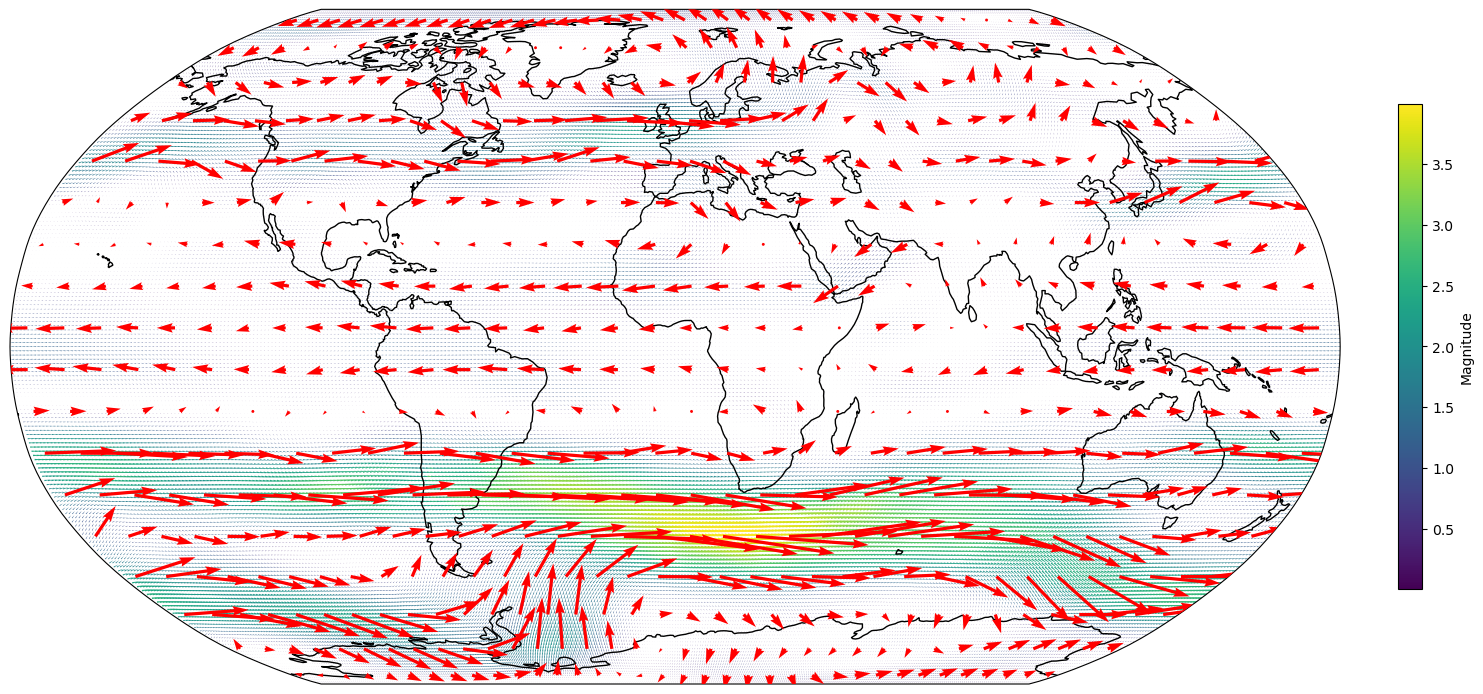

In [17]:
plat, plon, d_us_post, d_vs_post = sph_utils.project_to_latlon(points2, z_pred_sph_re)

plat_ds_re, plon_ds_re, d_us_ds_re, d_vs_ds_re = sph_utils.project_to_latlon(centres, recovered_avgs)

fig = plt.figure(figsize=(15, 10))
ax = plt.axes(projection=ccrs.Robinson())
ax.set_global()
ax.coastlines()

quiv = ax.quiver(plon, plat, d_us_post, d_vs_post, np.sqrt(np.power(d_us, 2) + np.power(d_vs, 2)),
                 transform=ccrs.PlateCarree(), headwidth=1, zorder=0, minlength=0)
quiv._init()
quiv2 = ax.quiver(plon_ds, plat_ds, d_us_ds_re, d_vs_ds_re, color='red', transform=ccrs.PlateCarree(), zorder=10)
plt.colorbar(mappable=quiv, label='Magnitude', fraction=0.04, pad=0.04, shrink=0.5)
plt.tight_layout()
plt.show()
# plt.savefig('plots/post-averaged-wind.png', dpi=500)


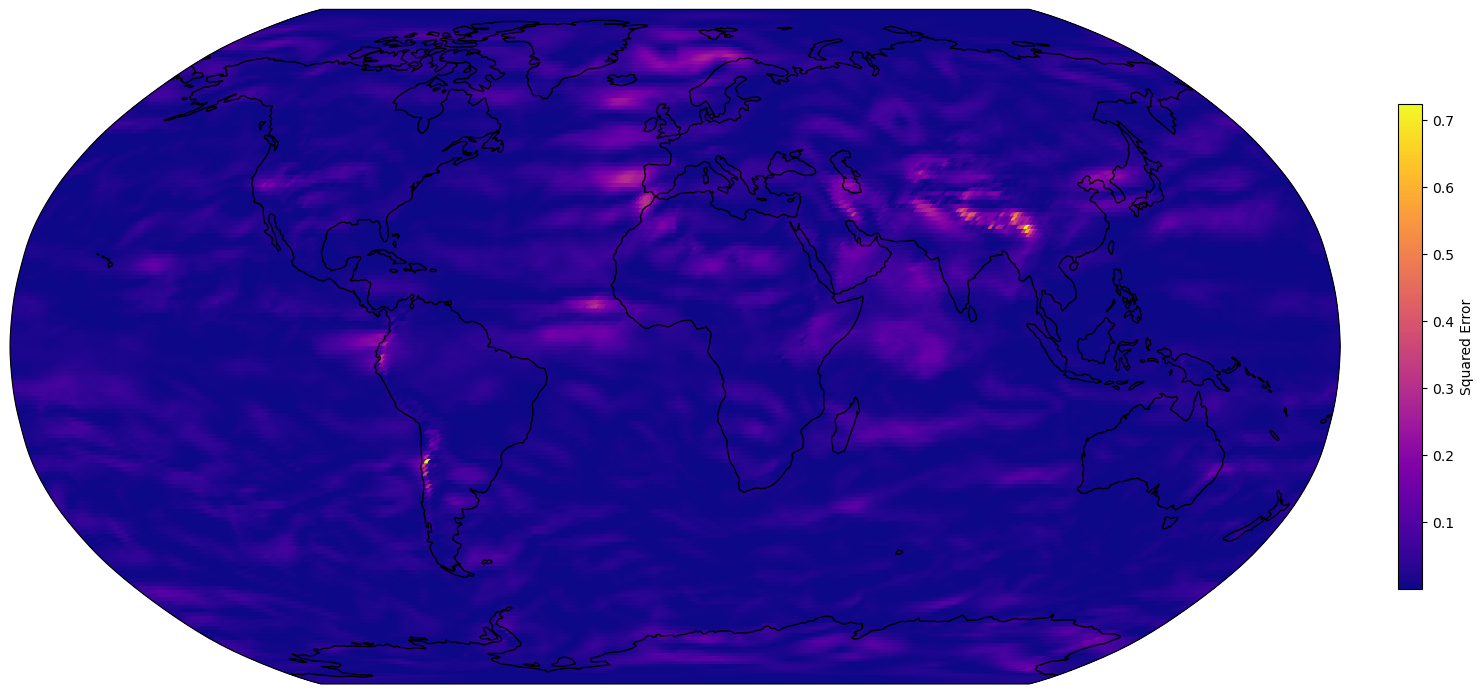

In [18]:

fig = plt.figure(figsize=(15, 10))
ax = plt.axes(projection=ccrs.Robinson())
ax.set_global()
ax.coastlines()

quiv = ax.scatter(plon, plat, c=np.linalg.norm(obs_vecs - z_pred_sph_re, axis=1) ** 2, transform=ccrs.PlateCarree(),
                  cmap='plasma')
plt.colorbar(mappable=quiv, label='Squared Error', fraction=0.04, pad=0.04, shrink=0.5)
plt.tight_layout()
plt.show()
# plt.savefig('plots/se-averaged-wind.png', dpi=500)


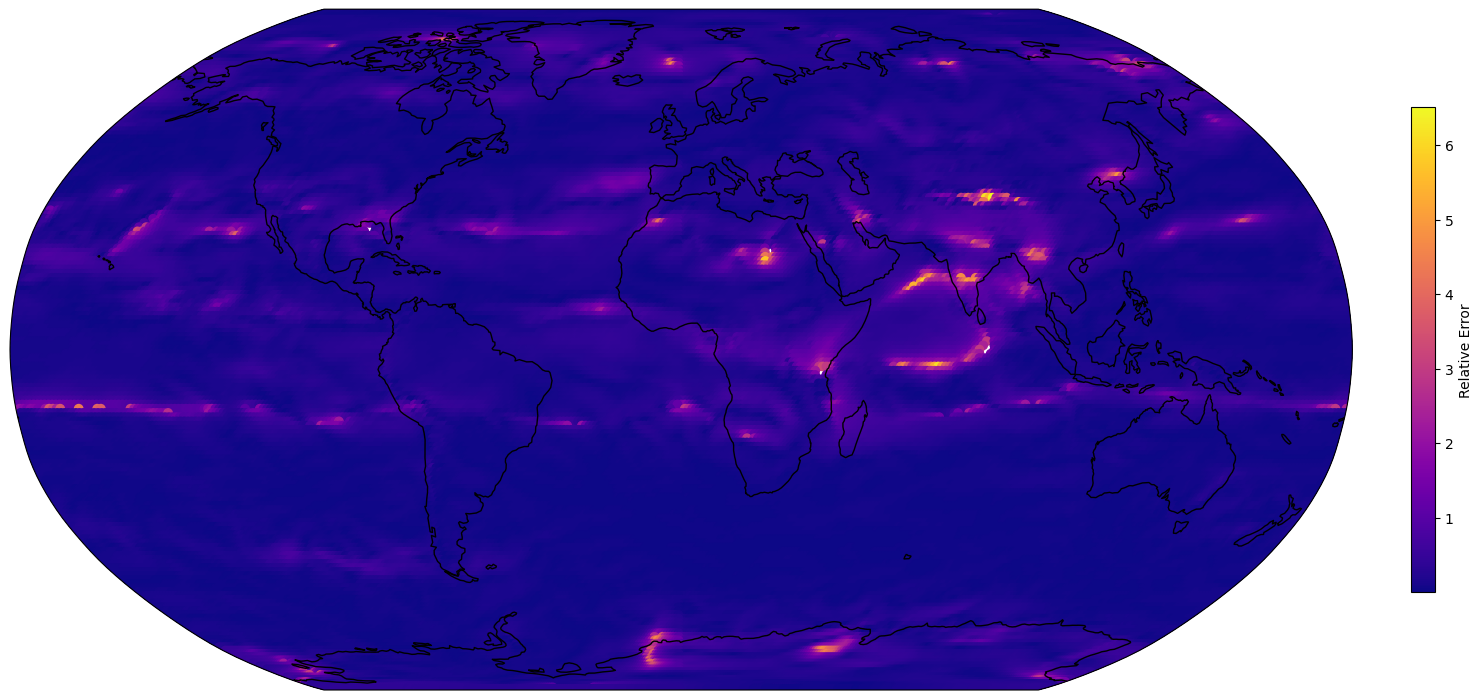

In [19]:
fig = plt.figure(figsize=(15, 10))
ax = plt.axes(projection=ccrs.Robinson())
ax.set_global()
ax.coastlines()

re_obs_vecs = np.where(np.linalg.norm(obs_vecs, axis=1) <= 0.05, np.nan, np.linalg.norm(obs_vecs, axis=1))
re_pred_vecs = np.where(np.linalg.norm(obs_vecs, axis=1) <= 0.05, np.nan,
                        np.linalg.norm(z_pred_sph_re - obs_vecs, axis=1))

quiv = ax.scatter(plon, plat, c=re_pred_vecs / re_obs_vecs, transform=ccrs.PlateCarree(), cmap='plasma')
plt.colorbar(mappable=quiv, label='Relative Error', fraction=0.04, pad=0.04, shrink=0.5)
plt.tight_layout()
plt.show()
# plt.savefig('plots/re-averaged-wind.png', dpi=500)


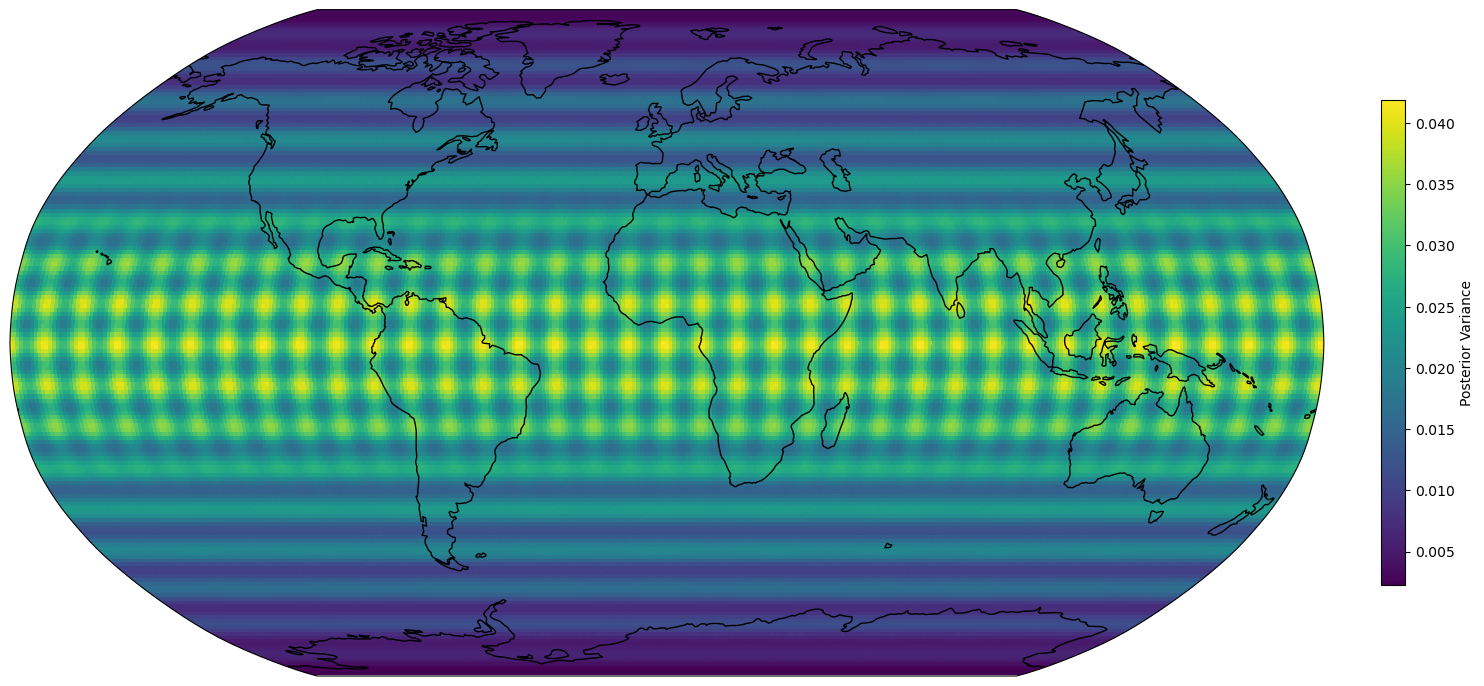

In [22]:
# Try 'C' first. If the plot looks like "barcode noise", try 'F'.
cov_grid = scalar_uncertainty.reshape(len(filtered_lats), len(filtered_lons), order='C')
cov_grid = np.flipud(cov_grid)
# 2. Setup Plot
fig = plt.figure(figsize=(15, 10))
ax = plt.axes(projection=ccrs.Robinson())
ax.set_global()
ax.coastlines()

im1 = ax.pcolormesh(filtered_lons, filtered_lats, cov_grid,
                    transform=ccrs.PlateCarree(),
                    cmap='viridis',
                    shading='nearest')

plt.colorbar(im1, fraction=0.04, pad=0.04, shrink=0.5, label='Posterior Variance')
plt.tight_layout()
plt.show()
# plt.savefig('plots/post-var-averaged-wind.png', dpi=500)

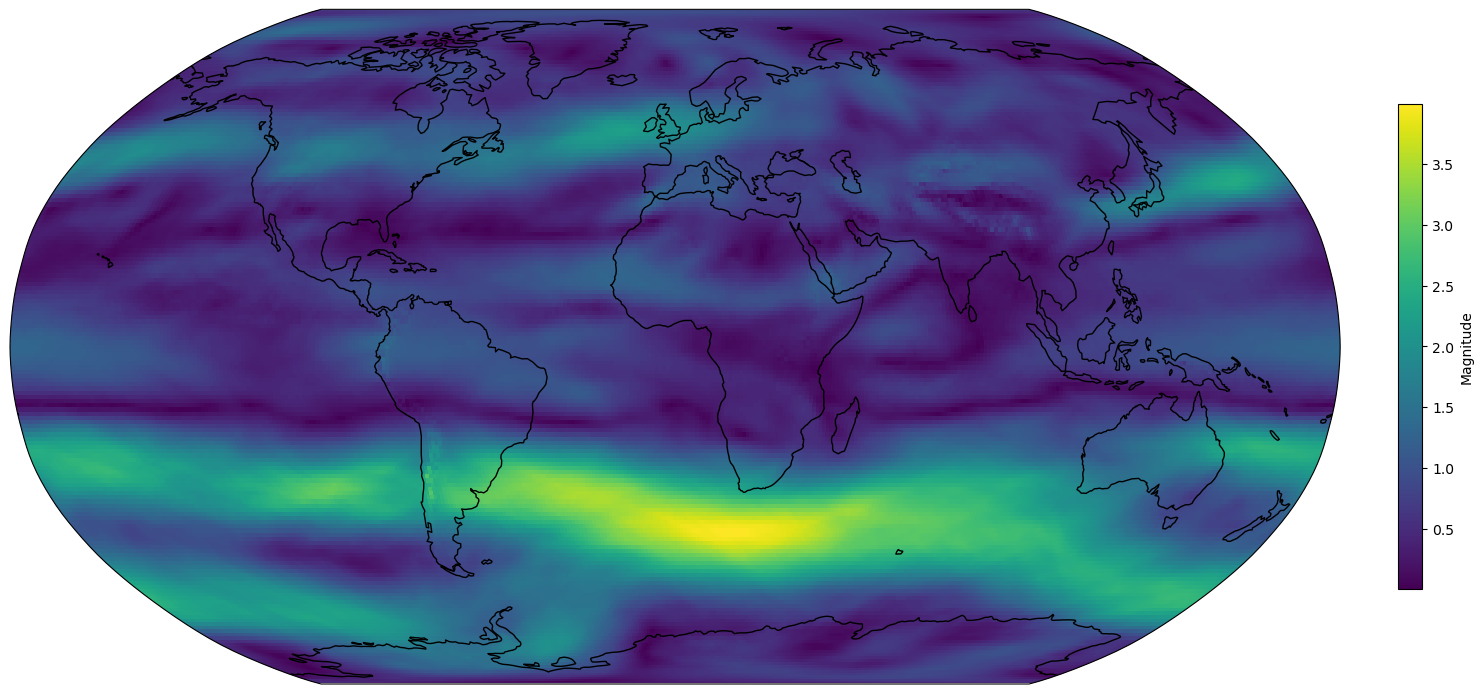

In [23]:
d_vecs = np.column_stack((d_us, d_vs))
mag = np.linalg.norm(d_vecs, axis=1)

mag_grid = mag.reshape(len(filtered_lats), len(filtered_lons), order='C')
mag_grid = np.flipud(mag_grid)
# 2. Setup Plot
fig = plt.figure(figsize=(15, 10))
ax = plt.axes(projection=ccrs.Robinson())
ax.set_global()
ax.coastlines()

im1 = ax.pcolormesh(filtered_lons, filtered_lats, mag_grid,
                    transform=ccrs.PlateCarree(),
                    cmap='viridis',
                    shading='nearest')

plt.colorbar(im1, fraction=0.04, pad=0.04, shrink=0.5, label='Magnitude')
plt.tight_layout()
plt.show()
# plt.savefig('plots/mag-averaged-wind.png', dpi=500)

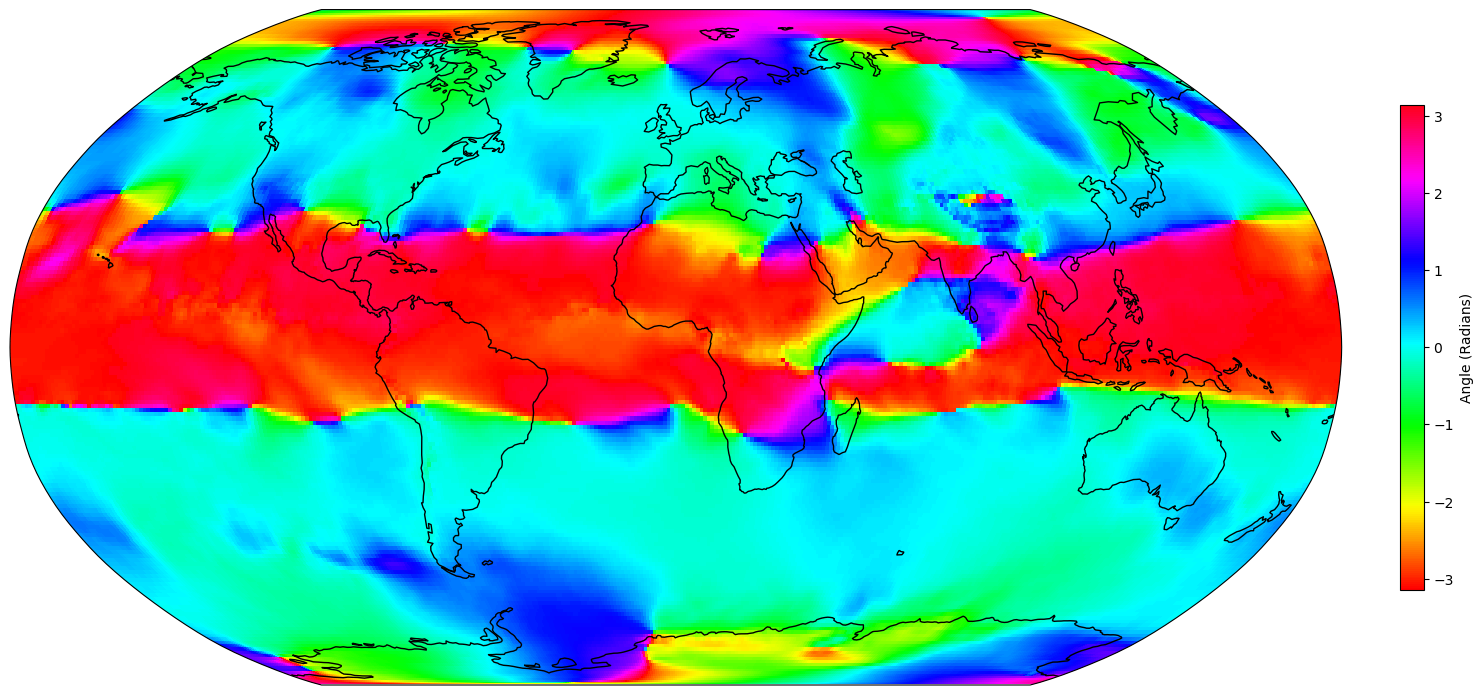

In [24]:
angle = np.arctan2(d_vs, d_us)

angle_grid = angle.reshape(len(filtered_lats), len(filtered_lons), order='C')
angle_grid = np.flipud(angle_grid)
# 2. Setup Plot
fig = plt.figure(figsize=(15, 10))
ax = plt.axes(projection=ccrs.Robinson())
ax.set_global()
ax.coastlines()

im1 = ax.pcolormesh(filtered_lons, filtered_lats, angle_grid,
                    transform=ccrs.PlateCarree(),
                    cmap='hsv',
                    shading='nearest')

plt.colorbar(im1, fraction=0.04, pad=0.04, shrink=0.5, label='Angle (Radians)')
plt.tight_layout()
plt.show()
# plt.savefig('plots/ang-averaged-wind.png', dpi=500)

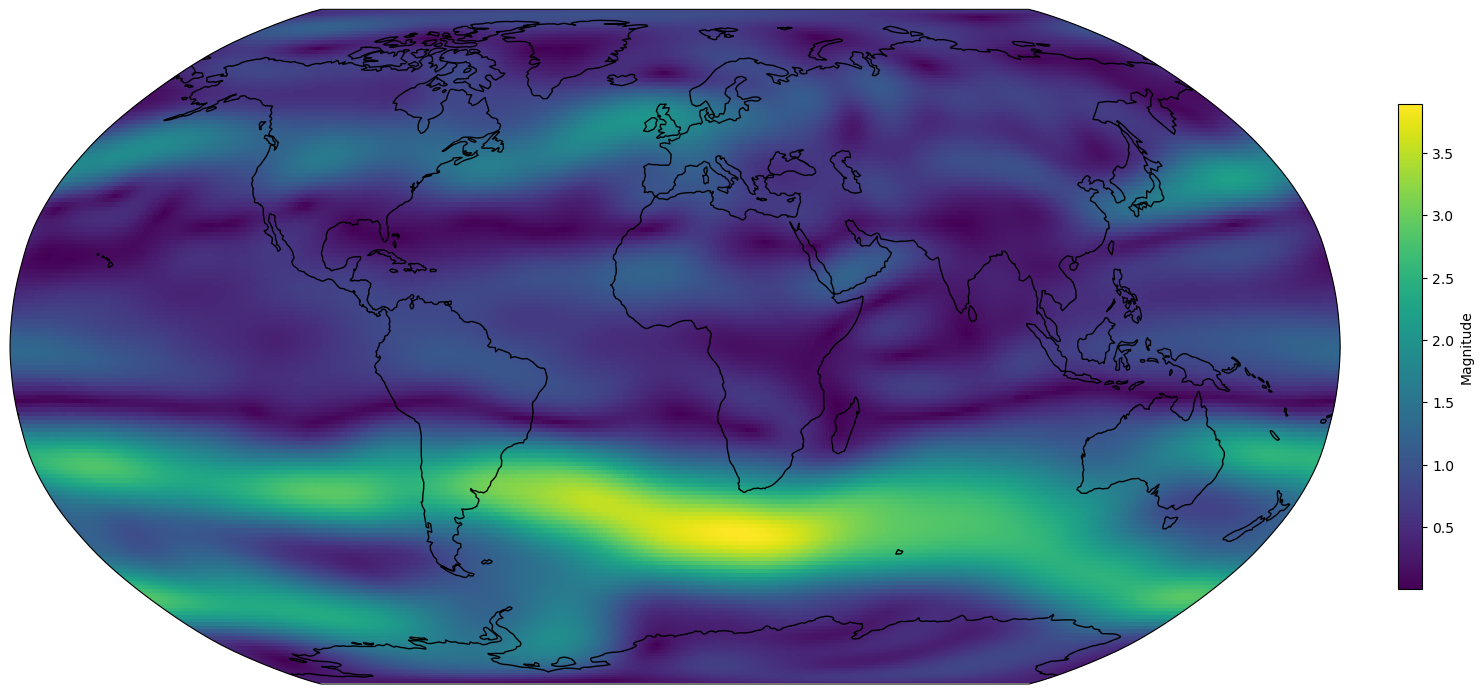

In [25]:
d_vecs_post = np.column_stack((d_us_post, d_vs_post))
mag_post = np.linalg.norm(d_vecs_post, axis=1)

mag_grid_post = mag_post.reshape(len(filtered_lats), len(filtered_lons), order='C')
mag_grid_post = np.flipud(mag_grid_post)
# 2. Setup Plot
fig = plt.figure(figsize=(15, 10))
ax = plt.axes(projection=ccrs.Robinson())
ax.set_global()
ax.coastlines()

im1 = ax.pcolormesh(filtered_lons, filtered_lats, mag_grid_post,
                    transform=ccrs.PlateCarree(),
                    cmap='viridis',
                    shading='nearest')

plt.colorbar(im1, fraction=0.04, pad=0.04, shrink=0.5, label='Magnitude')
plt.tight_layout()
plt.show()
# plt.savefig('plots/post-mag-averaged-wind.png', dpi=500)

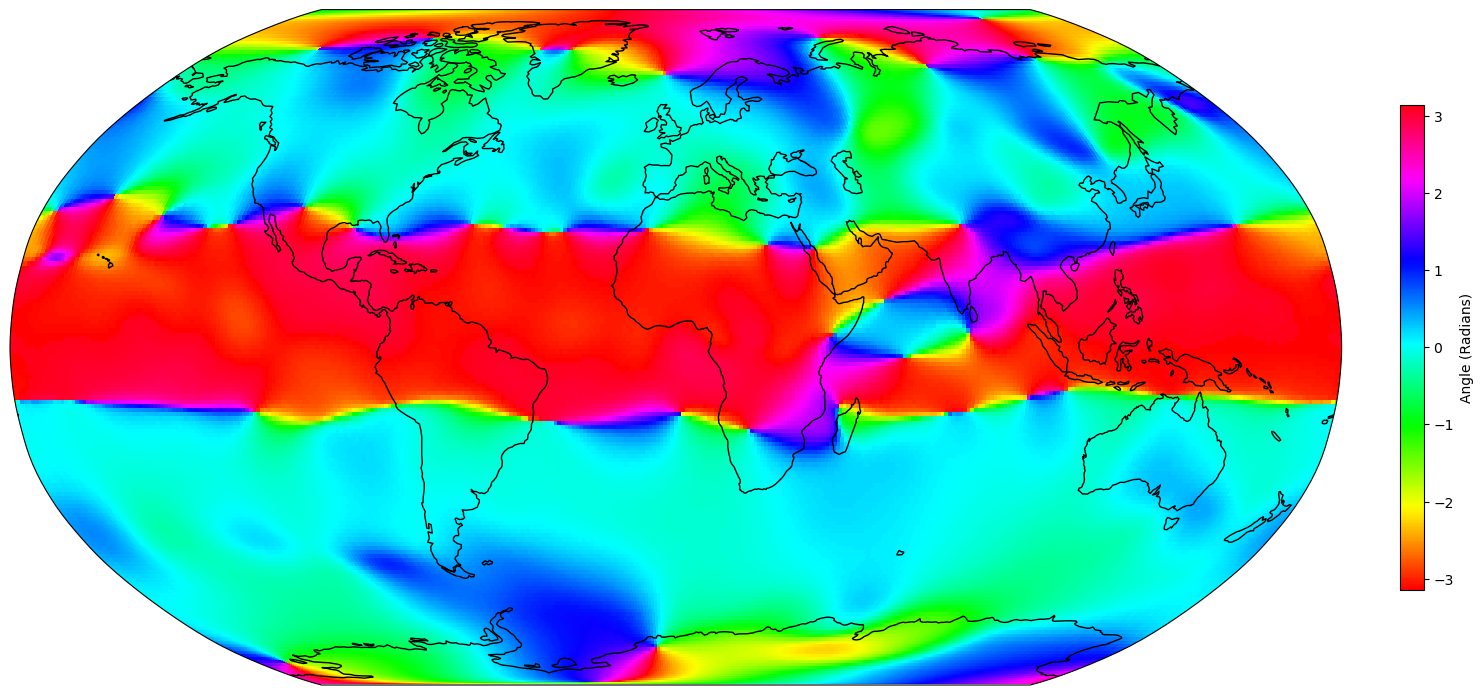

In [26]:
angle_post = np.arctan2(d_vs_post, d_us_post)

angle_grid_post = angle_post.reshape(len(filtered_lats), len(filtered_lons), order='C')
angle_grid_post = np.flipud(angle_grid_post)
# 2. Setup Plot
fig = plt.figure(figsize=(15, 10))
ax = plt.axes(projection=ccrs.Robinson())
ax.set_global()
ax.coastlines()

im1 = ax.pcolormesh(filtered_lons, filtered_lats, angle_grid_post,
                    transform=ccrs.PlateCarree(),
                    cmap='hsv',
                    shading='nearest')

plt.colorbar(im1, fraction=0.04, pad=0.04, shrink=0.5, label='Angle (Radians)')
plt.tight_layout()
plt.show()
# plt.savefig('plots/post-ang-averaged-wind.png', dpi=500)

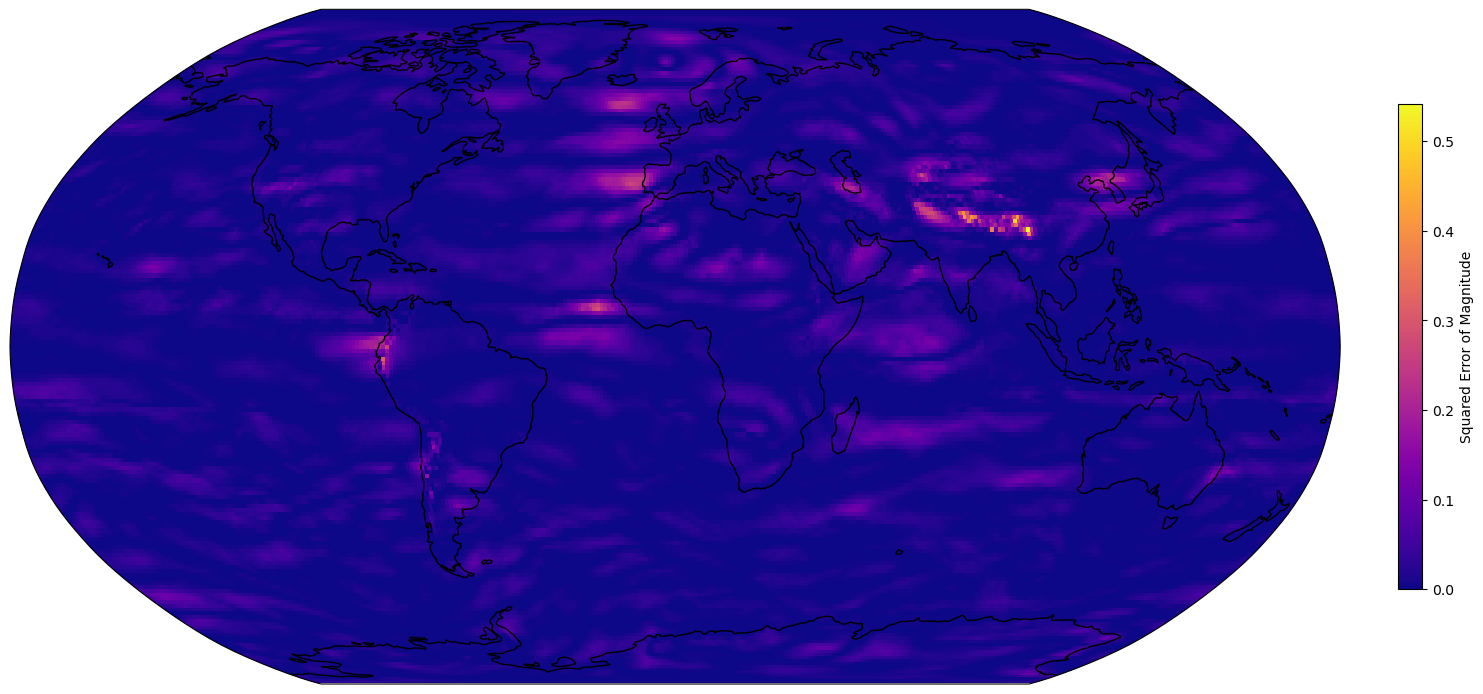

In [27]:

# 2. Setup Plot
fig = plt.figure(figsize=(15, 10))
ax = plt.axes(projection=ccrs.Robinson())
ax.set_global()
ax.coastlines()

im1 = ax.pcolormesh(filtered_lons, filtered_lats, (mag_grid - mag_grid_post) ** 2,
                    transform=ccrs.PlateCarree(),
                    cmap='plasma',
                    shading='nearest')

plt.colorbar(im1, fraction=0.04, pad=0.04, shrink=0.5, label='Squared Error of Magnitude')
plt.tight_layout()
plt.show()
# plt.savefig('plots/err-mag-averaged-wind.png', dpi=500)

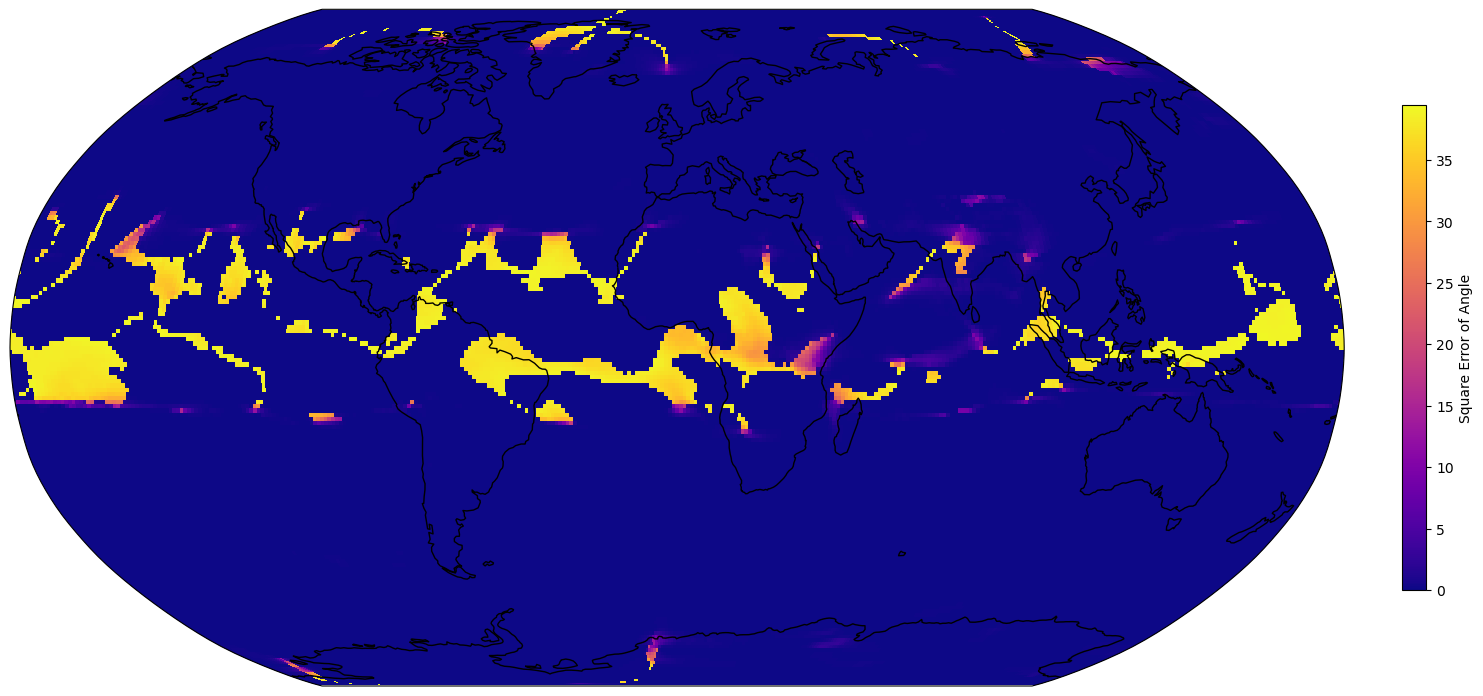

In [28]:

# 2. Setup Plot
fig = plt.figure(figsize=(15, 10))
ax = plt.axes(projection=ccrs.Robinson())
ax.set_global()
ax.coastlines()

im1 = ax.pcolormesh(filtered_lons, filtered_lats, (angle_grid - angle_grid_post) ** 2,
                    transform=ccrs.PlateCarree(),
                    cmap='plasma',
                    shading='nearest')

plt.colorbar(im1, fraction=0.04, pad=0.04, shrink=0.5, label='Square Error of Angle')
plt.tight_layout()
plt.show()
# plt.savefig('plots/err-ang-averaged-wind.png', dpi=500)

In [29]:
from tqdm import tqdm

# Reusing V_dense and Lambda_post (I - P) from the uncertainty calculation
V_dense = V.toarray()
Lambda_post = np.eye(P.shape[0]) - P

# The recovered mean vector (x_hat) is needed
# You should ensure x_hat is calculated using the numerically stable approach from the previous fix.
# x_hat = sigma_xbar.dot(w) OR x_hat = V.dot(F.T.dot(w))

# The true observations are the original obs_vecs (before downscaling)
true_obs = obs_vecs  # Shape (N_points, 3)

N_points = V_dense.shape[0] // 3
log_scores = np.zeros(N_points)
x_hat = x_hat.reshape(N_points, 3)  # Reshape mean to (N_points, 3)

for i in tqdm(range(N_points)):
    # 1. Extract Mean and True Observation
    mu_i = x_hat[i, :]
    x_i = true_obs[i, :]

    # 2. Extract the 3x3 Posterior Covariance Block (Sigma_i)
    V_i = V_dense[3 * i: 3 * i + 3, :]  # 3 x N_m block of V
    Sigma_i = V_i.dot(Lambda_post).dot(V_i.T)  # Sigma_i = V_i * Lambda_post * V_i.T
    Sigma_i += factor_nug * np.eye(3)

    # Ensure Sigma_i is numerically stable and symmetric
    Sigma_i = (Sigma_i + Sigma_i.T) / 2

    try:
        # 3. Calculate Log-Score components
        Sigma_i_inv = np.linalg.inv(Sigma_i)

        # Mahalanobis Distance Squared: (x - mu)^T * Sigma^-1 * (x - mu)
        diff = x_i - mu_i
        mahal_sq = diff.T @ Sigma_i_inv @ diff

        # Determinant term
        log_det_Sigma = np.log(np.linalg.det(Sigma_i))

        # Log-Score
        log_scores[i] = -0.5 * (mahal_sq + log_det_Sigma + 3 * np.log(2 * np.pi))

    except np.linalg.LinAlgError:
        # Handle singular matrix (should be rare with nugget regularization)
        print('.')
        log_scores[i] = np.nan

# Average Log-Score
avg_log_score = np.nanmean(log_scores)
print(f"Average Log-Score: {avg_log_score:.4f}")
print(f"Sum of Log-Likelihoods: {np.nansum(log_scores):.4f}")

  0%|          | 0/64440 [00:00<?, ?it/s]C:\Users\mg874\AppData\Local\Temp\ipykernel_1924\3366387488.py:43: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  log_scores[i] = -0.5 * (mahal_sq + log_det_Sigma + 3 * np.log(2 * np.pi))
100%|██████████| 64440/64440 [00:47<00:00, 1355.84it/s]

Average Log-Score: 2.9912
Sum of Log-Likelihoods: 192752.1834


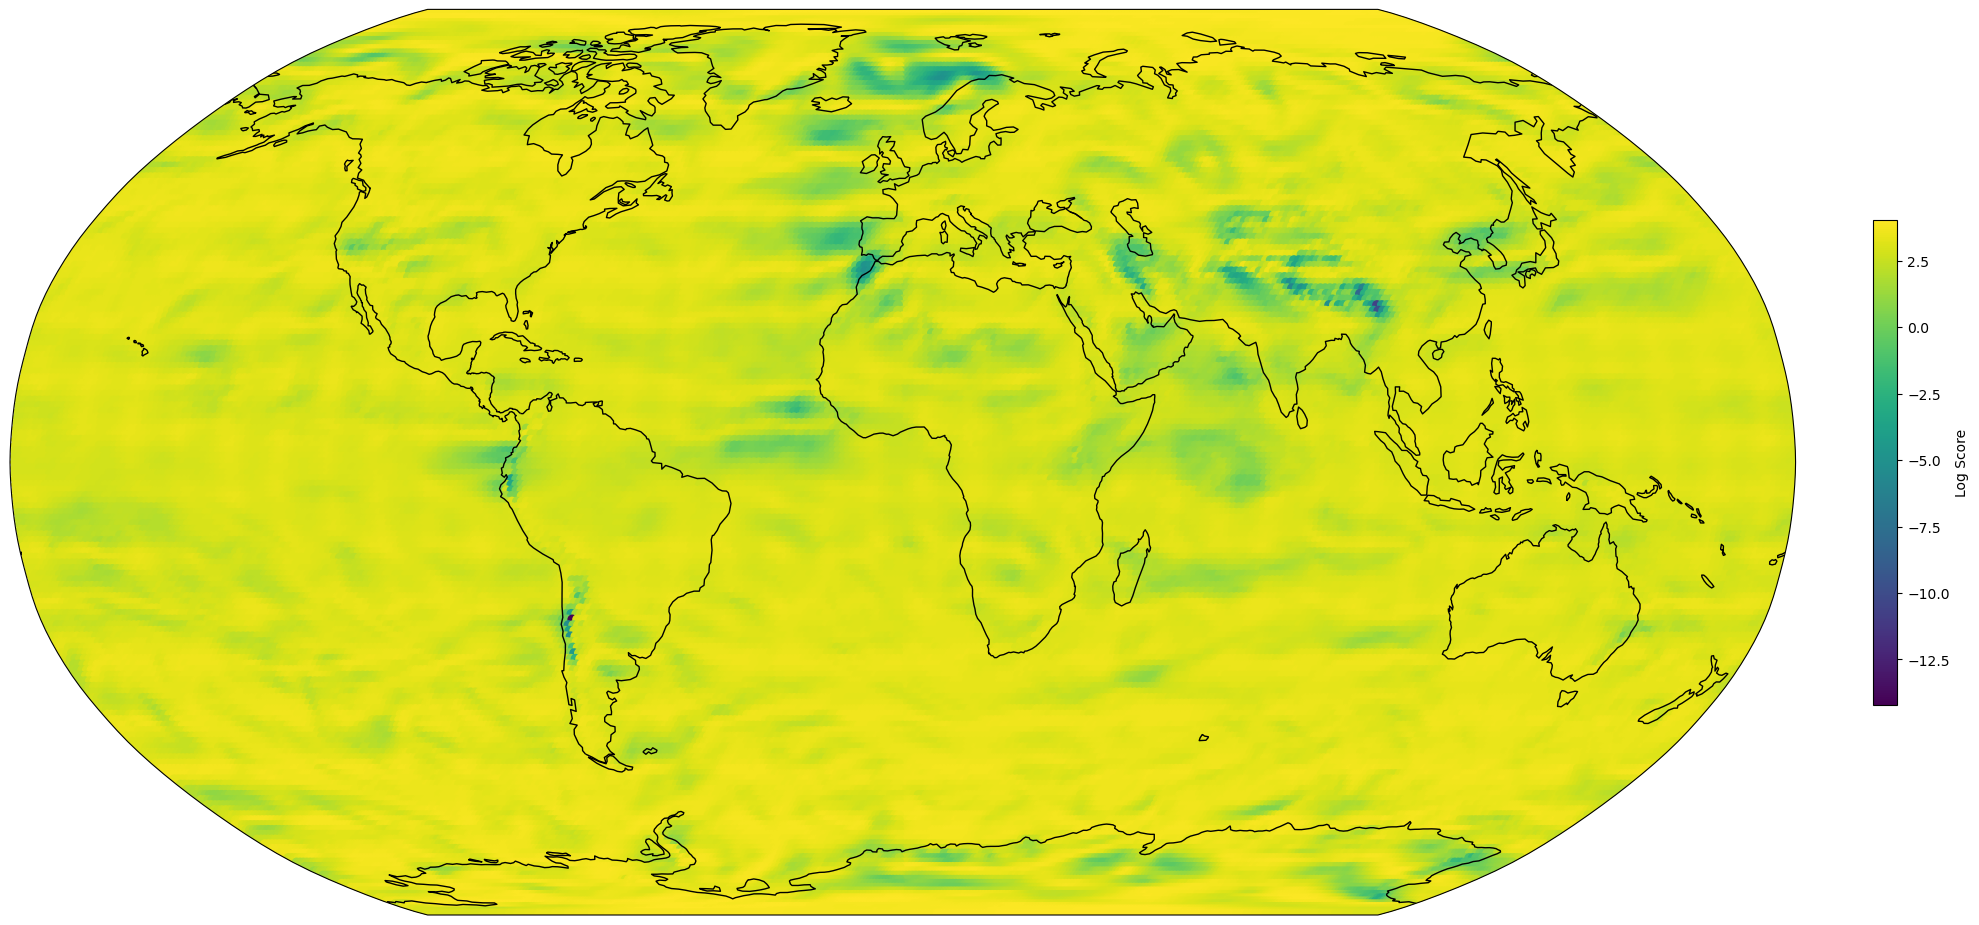

In [30]:
log_score_grid = log_scores.reshape(len(filtered_lats), len(filtered_lons), order='C')

fig = plt.figure(figsize=(20, 10))
ax = plt.axes(projection=ccrs.Robinson())
ax.set_global()
ax.coastlines()

# log_score_grid, aug_lons = add_cyclic_point(log_score_grid, coord=filtered_lons)

# grid_lat, grid_lon = np.meshgrid(filtered_lats, filtered_lons)

# im1 = plt.contourf(aug_lons, filtered_lats, log_score_grid, levels=15, transform=ccrs.PlateCarree())
im1 = plt.scatter(plon, plat, c=log_score_grid, transform=ccrs.PlateCarree())

# quiv = ax.quiver(plon, plat, d_us, d_vs, np.sqrt(np.power(d_us, 2) + np.power(d_vs, 2)), transform=ccrs.PlateCarree(), headwidth=1)
plt.colorbar(mappable=im1, fraction=0.04, pad=0.04, shrink=0.5, label='Log Score')

plt.tight_layout()
plt.show()
# plt.savefig('plots/ls-averaged-wind.png', dpi=500)

In [33]:
def solve_gmrf_downscale(coarse_data, n_lat=180, n_lon=358, kappa=0.1):
    """
    kappa: Inverse range parameter (related to Matern 0.5 length scale)
    """
    N = n_lat * n_lon

    # 1. Build Sparse Precision Matrix Q (2D Laplacian + Identity)
    # This represents the Matern 0.5 prior
    main_diag = np.ones(N) * (4 + kappa ** 2)
    side_diag = -np.ones(N)

    Q = scipy.sparse.spdiags([side_diag, side_diag, main_diag, side_diag, side_diag],
                             [-n_lon, -1, 0, 1, n_lon], N, N).tocsc()

    # 2. Build Observation Matrix H (Averaging 10x10 blocks)
    # Maps N_fine points to M_coarse blocks
    H_rows = []
    H_cols = []
    H_vals = []

    # Assuming coarse_data is (18, 36)
    m_lat, m_lon = coarse_data.shape
    for i in range(m_lat):
        for j in range(m_lon):
            block_idx = i * m_lon + j
            # Find indices of all 1-degree points inside this 10x10 block
            for r in range(i * 10, (i + 1) * 10):
                for c in range(j * 10, (j + 1) * 10):
                    fine_idx = r * n_lon + (c % n_lon)  # handle longitude wrap
                    H_rows.append(block_idx)
                    H_cols.append(fine_idx)
                    H_vals.append(1.0 / 100.0)  # Average of 100 points

    H = scipy.sparse.csc_matrix((H_vals, (H_rows, H_cols)), shape=(m_lat * m_lon, N))

    # 3. Solve the System (Posterior Mean)
    # Posterior Precision: Q_post = Q + H.T @ R^-1 @ H
    # Using small noise R = sigma^2 * I
    sigma_obs = 0.05
    R_inv = (1.0 / sigma_obs ** 2)

    rhs = H.T @ (R_inv * coarse_data.ravel())
    Q_post = Q + H.T @ (R_inv * H)

    # Use sparse LU decomposition for efficiency
    solver = scipy.sparse.linalg.splu(Q_post)
    mu_post = solver.solve(rhs)

    return mu_post.reshape(n_lat, n_lon), solver


# Usage
u_fine, u_solver = solve_gmrf_downscale(d_us_ds.reshape((18, 36)))
v_fine, v_solver = solve_gmrf_downscale(d_vs_ds.reshape((18, 36)))

In [34]:
gp_uv = sph_utils.project_to_xyz(points2, u_fine.ravel(), v_fine.ravel())
print("MSE(-ish): " + str(np.mean(np.linalg.norm(obs_vecs - gp_uv, axis=1) ** 2)))

MSE(-ish): 0.7043653030747302


In [35]:
def calculate_gmrf_log_score(y_true, mu_post, solver):
    """
    y_true: High-res validation data (1-degree)
    mu_post: Result from GMRF
    solver: The splu object from the fit
    """
    n = y_true.size
    y_diff = (y_true.ravel() - mu_post.ravel())

    # 1. Log-determinant from LU decomposition
    # diag(U) are the diagonal elements of the U matrix in LU
    log_det = np.sum(np.log(np.abs(solver.U.diagonal())))

    # 2. Quadratic form: (y-mu).T @ Q_post @ (y-mu)
    # Note: Using the solver to get the precision contribution
    quad_form = y_diff.T @ (solver.solve(y_diff, trans='N'))  # This is slightly simplified

    # Log score (normalized per point)
    log_score = 0.5 * (log_det - quad_form - n * np.log(2 * np.pi))
    return log_score / n


u_score = calculate_gmrf_log_score(d_us, u_fine, u_solver)
v_score = calculate_gmrf_log_score(d_vs, v_fine, v_solver)

In [36]:
joint_log_score_map = u_score + v_score

# Total average performance
total_avg_log_score = np.mean(joint_log_score_map)
print(total_avg_log_score)

-0.959479450343524


In [37]:
from scipy.spatial import cKDTree


def interpolate_unaligned_to_target(d_obs, plat_ds, plon_ds, target_lat_grid, target_lon_grid, k=4):
    """
    Interpolates unaligned data to match the EXACT shape of the target grid.
    target_lat_grid: The 1D or 2D array representing your 180 latitudes.
    target_lon_grid: The 1D or 2D array representing your 360 longitudes.
    """
    # 1. Prepare Coarse Data (Input)
    pts_lat = plat_ds.flatten()
    pts_lon = plon_ds.flatten()
    vals = d_obs.flatten()

    # Wrap Longitude to handle the 0/360 boundary
    lats_w = np.concatenate([pts_lat, pts_lat, pts_lat])
    lons_w = np.concatenate([pts_lon - 360, pts_lon, pts_lon + 360])
    vals_w = np.concatenate([vals, vals, vals])

    # Build the KDTree
    tree = cKDTree(np.column_stack([lats_w, lons_w]))

    # 2. Prepare Target Grid (Output)
    # We use the original arrays passed in to define the query points
    # This ensures the output matches your GPO grid perfectly
    query_pts = np.column_stack([target_lat_grid.flatten(), target_lon_grid.flatten()])

    # 3. Query and Interpolate
    dists, idx = tree.query(query_pts, k=k)

    # Inverse Distance Weighting
    weights = 1.0 / np.maximum(dists, 1e-10)
    weights_sum = np.sum(weights, axis=1)
    interpolated = np.sum(vals_w[idx] * weights, axis=1) / weights_sum

    # 4. Final Reshape
    # We force the result into the same shape as your input target_lat_grid
    return interpolated.reshape(target_lat_grid.shape)


# --- Usage ---
# Pass your fine-grid lat/lon arrays directly
u_bilinear = interpolate_unaligned_to_target(d_us_ds, plat_ds, plon_ds, plat, plon)
v_bilinear = interpolate_unaligned_to_target(d_vs_ds, plat_ds, plon_ds, plat, plon)


In [38]:
bi_uv = sph_utils.project_to_xyz(points2, u_bilinear.ravel(), v_bilinear.ravel())
print("MSE(-ish): " + str(np.mean(np.linalg.norm(obs_vecs - bi_uv, axis=1) ** 2)))

MSE(-ish): 0.0726681013621884
